In [ ]:
import numpy as np

# 1. 基础索引与切片
arr = np.array([0, 1, 2, 3, 4, 5])
arr[0]       # 取第0个元素 → 0
arr[1:4]     # 切片（左闭右开）→ [1,2,3]
arr[-1]      # 取最后一个 → 5

# 2. 布尔索引（数据筛选）
arr[arr > 2] # 取大于2的元素 → [3,4,5]

# 3. 常用统计（计算损失、准确率时常用）
np.sum(arr)   # 总和 → 15
np.mean(arr)  # 均值 → 2.5
np.argmax(arr)# 最大值的索引 → 5
np.argmin(arr)# 最小值的索引 → 0

# 4. 数组拼接与追加
np.concatenate([arr, arr])  # 拼接 → [0,1,2,3,4,5,0,1,2,3,4,5]
np.append(arr, 6)            # 追加元素 → [0,1,2,3,4,5,6]

# 5. 类型转换（深度学习常用：转float32）
arr.astype(np.float32)  # 转为float32类型

In [ ]:
arr = np.array([
    [1, 2, 3],  # 第0行
    [4, 5, 6],  # 第1行
    [7, 8, 9]   # 第2行
])

# 1. 索引与切片（取行、取列、取局部）
arr[0]         # 取第0行 → [1,2,3]
arr[:, 0]      # 取第0列 → [1,4,7]
arr[1:, 1:]    # 取右下角 → [[5,6],[8,9]]

# 2. 形状变换（数据预处理常用）
arr.reshape(1, 9)  # 转成1行9列 → [[1,2,3,4,5,6,7,8,9]]
arr.T              # 转置（行变列，列变行）→ [[1,4,7],[2,5,8],[3,6,9]]
arr.flatten()      # 展平成1维 → [1,2,3,4,5,6,7,8,9]

# 3. 矩阵运算（线性回归、神经网络前向传播）
np.dot(arr, arr)   # 矩阵乘法
arr @ arr          # 等价于np.dot（Python3.5+）

# 4. 按轴统计（axis=0列方向，axis=1行方向）
np.sum(arr, axis=0)   # 每列求和 → [12,15,18]
np.mean(arr, axis=1)  # 每行均值 → [2,5,8]
np.argmax(arr, axis=1)# 每行最大值索引 → [2,2,2]
np.sum(arr, axis=0, keepdims=True)  # 保持二维 → (1,3 ) 场景：计算均值后要和原数组相减，必须用keepdims才能正确广播


# 5. 拼接与分割（数据集合并/划分）
np.concatenate([arr, arr], axis=0)  # 按行拼接（增加样本）
np.concatenate([arr, arr], axis=1)  # 按列拼接（增加特征）
np.split(arr, 3, axis=0)             # 按行分割成3份

# 6.条件替换（np.where：数组版三元运算符）
np.where(arr > 5, 1, 0)       # 大于5的换成1，否则0

In [ ]:
# 示例：3个样本，每个是2行2列的“小图片”
arr = np.array([
    [[1, 2], [3, 4]],    # 样本0
    [[5, 6], [7, 8]],    # 样本1
    [[9, 10], [11, 12]]  # 样本2
])

# 1. 索引与切片（取样本、取局部区域）
arr[0]               # 取第0个样本 → [[1,2],[3,4]]
arr[1:, :, 0]        # 取第1-2个样本的第0列 → [[5,7],[9,11]]
arr[:, 0, 0]         # 取所有样本的(0,0)位置 → [1,5,9]

# 2. 维度扩展/压缩（适配模型输入）
arr[np.newaxis, ...]  # 增加第0维（如batch维度）→ (1,3,2,2)
np.squeeze(arr)        # 压缩长度为1的维度（若有的话）

# 3. 按轴统计（时间序列/图像特征提取）
np.mean(arr, axis=0)  # 所有样本对应位置取平均 → [[5,6],[7,8]]
np.max(arr, axis=1)   # 每个样本的行方向取最大 → [[3,4],[7,8],[11,12]]

# 4. 形状变换（展平成2维输入全连接层）
arr.reshape(3, 4)     # 转成(样本数, 特征数) → [[1,2,3,4],[5,6,7,8],[9,10,11,12]]

# 5. 拼接（增加样本）
np.concatenate([arr, arr], axis=0)  # 按第0维拼接 → (6,2,2)

# 广播

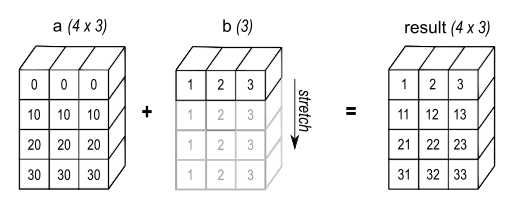

In [ ]:
def can_broadcast(x, y):
    print("x.shape:")
    print(x, x.shape)
    print("y.shape:")
    print(y, y.shape)
    print("x-y:")
    print(x - y)
    


In [38]:
import numpy as np
x = np.array([[1,2,3],[1,2,3]])
y = np.random.rand(3)
can_broadcast(x,y)
y = np.random.rand(1,3)
can_broadcast(x,y)
y = np.random.rand(2,1)
can_broadcast(x,y)


x.shape:
[[1 2 3]
 [1 2 3]] (2, 3)
y.shape:
[0.13619512 0.01591776 0.69226397] (3,)
x-y:
[[0.86380488 1.98408224 2.30773603]
 [0.86380488 1.98408224 2.30773603]]
x.shape:
[[1 2 3]
 [1 2 3]] (2, 3)
y.shape:
[[0.64300871 0.21542263 0.99322375]] (1, 3)
x-y:
[[0.35699129 1.78457737 2.00677625]
 [0.35699129 1.78457737 2.00677625]]
x.shape:
[[1 2 3]
 [1 2 3]] (2, 3)
y.shape:
[[0.81809583]
 [0.1909342 ]] (2, 1)
x-y:
[[0.18190417 1.18190417 2.18190417]
 [0.8090658  1.8090658  2.8090658 ]]
